[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/stats/significance-tests.ipynb)

# Significance tests

A sample is noisy, so a difference that you see in a sample can come from chance.
A significance test tells you how often chance alone gives a result at least as extreme as yours.
This notebook builds such a test by simulation with a coin, and then runs tests with SciPy and statsmodels.

Sections: Toss a coin 100,000 times, One sample of 100 tosses, What a fair coin does, The p-value, A biased coin, The binomial test, Compare two groups with a t-test, Other tests, Significance and effect size.

Packages beyond the standard library: `numpy`, `matplotlib`, `scipy`, `statsmodels`.
Install them with `uv add numpy matplotlib scipy statsmodels` (or `pip install`).
Colab already has all four.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from statsmodels.stats.proportion import proportions_ztest

# Figure settings: a larger font, and tick marks drawn behind the data.
plt.rcParams.update({"font.size": 14, "axes.axisbelow": True})

## Toss a coin 100,000 times

Is a coin fair?
A fair coin gives heads 50% of the time.
One way to check a coin is to toss it very many times.

The function below simulates 100,000 tosses of a coin with a given chance of heads.
`rng.random(100_000)` returns 100,000 random numbers between 0 and 1, and a toss is a head when its number is below the chance of heads.
The function draws the two counts as bars and returns the number of heads.

In [2]:
def coin_bar(rng, chance_of_heads):
    """Toss a coin 100,000 times, plot the two counts, and return the number of heads."""
    heads = int((rng.random(100_000) < chance_of_heads).sum())
    tails = 100_000 - heads
    plt.bar([0, 1], [tails, heads])
    plt.xticks([0, 1], ["Tail (0)", "Head (1)"])
    plt.ylabel("Frequency")
    plt.show()
    return heads


rng = np.random.default_rng(2026)

First, a fair coin.

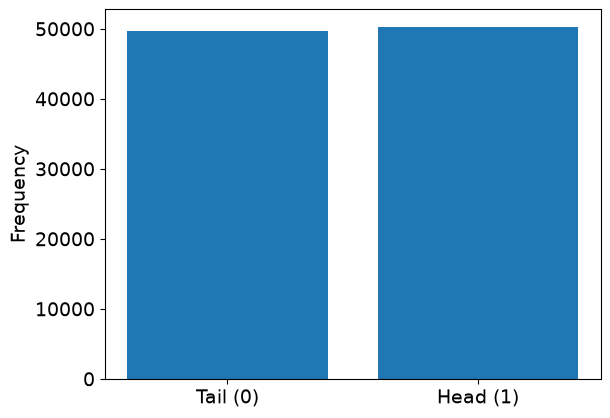

50,280 heads and 49,720 tails


In [3]:
heads = coin_bar(rng, 0.5)
print(f"{heads:,} heads and {100_000 - heads:,} tails")

The fair coin gives 50,280 heads and 49,720 tails.
The two bars have almost the same height.

Next, a coin with a 75% chance of heads.

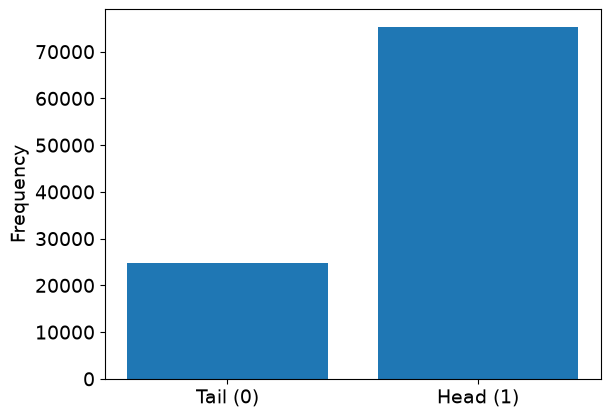

75,315 heads and 24,685 tails


In [4]:
heads = coin_bar(rng, 0.75)
print(f"{heads:,} heads and {100_000 - heads:,} tails")

This coin gives 75,315 heads and 24,685 tails.
You can see the bias without any test.

Last, a coin with a 51% chance of heads.

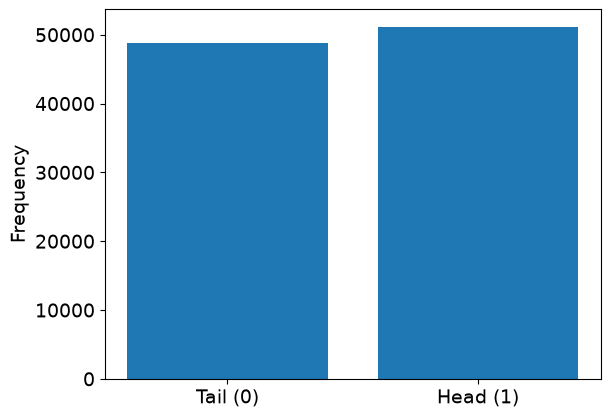

51,148 heads and 48,852 tails


In [5]:
heads = coin_bar(rng, 0.51)
print(f"{heads:,} heads and {100_000 - heads:,} tails")

This coin gives 51,148 heads and 48,852 tails.
The plot looks like the plot of the fair coin.
The plot alone cannot tell you whether the difference is real or noise.

The three cells draw from one random number generator.
Run them in this order to get these numbers.

## One sample of 100 tosses

In practice you cannot toss the coin 100,000 times, because collecting data costs time and money.
You have one small sample.

Suppose you toss the coin 100 times and get 60 heads.
Is the coin biased?
A fair coin can also give 60 heads by chance.
The question is how often that happens.

## What a fair coin does

The null hypothesis is the claim that nothing is going on.
Here the null hypothesis is that the coin is fair.

To see what a fair coin does, simulate it.
One run is 100 tosses of a fair coin.
`rng.binomial(n=100, p=0.5, size=100_000)` repeats the run 100,000 times and returns the number of heads in each run.
`bins=np.arange(24.5, 76.5)` gives one bin for each number of heads from 25 to 75.

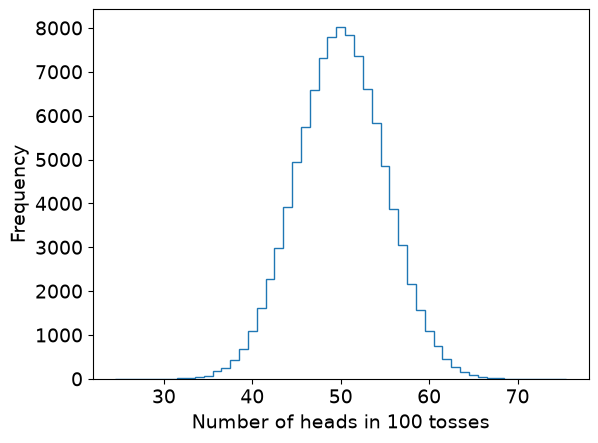

In [6]:
rng = np.random.default_rng(415)
# number of heads in each run of 100 tosses
fair_runs = rng.binomial(n=100, p=0.5, size=100_000)

plt.hist(fair_runs, histtype="step", bins=np.arange(24.5, 76.5))
plt.xlabel("Number of heads in 100 tosses")
plt.ylabel("Frequency")
plt.show()

Most runs end with about 50 heads.
Some runs end far from 50, although the coin is fair.

## The p-value

You observed 60 heads.
That is 10 more than the 50 heads that a fair coin gives on average.
How many of the fair runs are at least that far from 50?
These are the runs with 60 or more heads, and the runs with 40 or fewer.

In [7]:
far = np.abs(fair_runs - 50) >= 10
far.mean()

np.float64(0.05676)

The share is 0.05676, or 5.7% of the runs.
This share is the p-value: the probability of a result at least as extreme as yours, if the null hypothesis is true.

Here p = 0.057.
People often use 0.05 as the threshold.
p > 0.05, so you cannot reject the null hypothesis.
This does not prove that the coin is fair.

The next plot shows the p-value.
The red line is at the 60 heads that you observed.
The filled bars are the runs at least as far from 50.

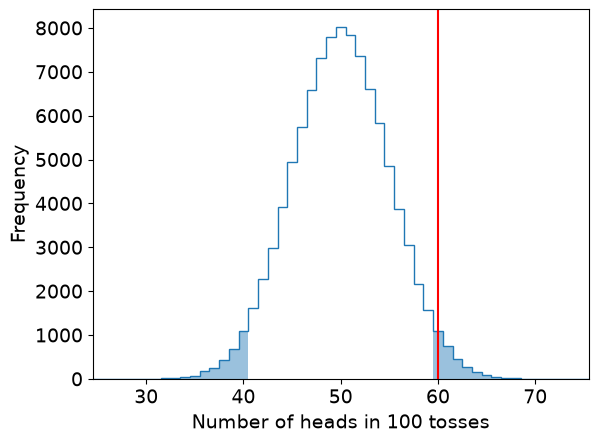

In [8]:
bins = np.arange(24.5, 76.5)

plt.hist(fair_runs, histtype="step", bins=bins, color="C0")
plt.hist(fair_runs[fair_runs >= 60], bins=bins, color="C0", alpha=0.45)
plt.hist(fair_runs[fair_runs <= 40], bins=bins, color="C0", alpha=0.45)
plt.axvline(60, color="red")
plt.xlim(24.5, 75.5)
plt.xlabel("Number of heads in 100 tosses")
plt.ylabel("Frequency")
plt.show()

The filled bars on both sides together hold 5.7% of the runs.

## A biased coin

Now suppose the coin is biased and gives heads 60% of the time.
Simulate 100,000 runs of 100 tosses with this coin, and plot them next to the fair runs.

The cell draws from the same generator as the fair runs.
Run the cells in order to get the numbers below.

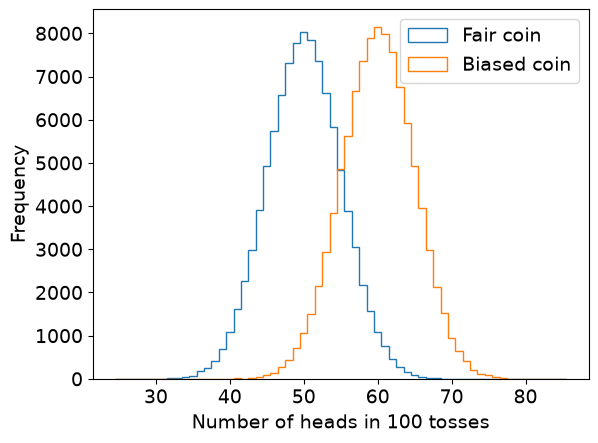

In [9]:
biased_runs = rng.binomial(n=100, p=0.6, size=100_000)

bins = np.arange(24.5, 86.5)
plt.hist(fair_runs, histtype="step", bins=bins, label="Fair coin")
plt.hist(biased_runs, histtype="step", bins=bins, label="Biased coin")
plt.legend()
plt.xlabel("Number of heads in 100 tosses")
plt.ylabel("Frequency")
plt.show()

The runs of the biased coin are centered at 60 heads.
The two distributions still overlap a lot.

Which results give p < 0.05?
The next cell computes the p-value for 60 heads again, and then for 61 heads.

In [10]:
print((np.abs(fair_runs - 50) >= 10).mean())    # 60 heads
print((np.abs(fair_runs - 50) >= 11).mean())    # 61 heads

0.05676
0.03509


The p-value is 0.057 for 60 heads and 0.035 for 61 heads.
A run needs 61 or more heads to give p < 0.05.
How many runs of the biased coin get there?

In [11]:
(biased_runs >= 61).mean()

np.float64(0.46204)

The share is 0.462: only 46% of the biased runs have 61 or more heads.
With one run of 100 tosses, the test misses the bias more than half of the time.
A test can miss a difference that is real.

More tosses in each run make both distributions narrower, so the overlap gets smaller.

## The binomial test

You do not need the simulation.
The binomial test computes the p-value directly.
`scipy.stats.binomtest(60, n=100, p=0.5)` tests 60 heads in 100 tosses against a coin with a 50% chance of heads.

In [12]:
scipy.stats.binomtest(60, n=100, p=0.5).pvalue

np.float64(0.05688793364098089)

The p-value is 0.0569.
It is the same as the result of the simulation, 0.057.

Now test 600 heads in 1,000 tosses.
The share of heads is the same, 60%, and the sample is 10 times as large.

In [13]:
scipy.stats.binomtest(600, n=1000, p=0.5).pvalue

np.float64(2.728464156066025e-10)

The p-value is 2.7e-10, which is almost 0.
The amount of data matters as much as the size of the difference.

## Compare two groups with a t-test

A more typical question is whether two groups have different mean values.
The t-test answers this question.
Its null hypothesis is that the two groups have the same mean.

The example is two simulated groups of 200 heights each.
The heights of group A come from a normal distribution with a mean of 170 cm, and the heights of group B from one with a mean of 175 cm.
The standard deviation is 10 cm in both groups.

In [14]:
rng = np.random.default_rng(2026)
group_a = rng.normal(loc=170, scale=10, size=200)    # heights in cm
group_b = rng.normal(loc=175, scale=10, size=200)

print(f"Mean of group A: {group_a.mean():.2f}")
print(f"Mean of group B: {group_b.mean():.2f}")

Mean of group A: 170.74
Mean of group B: 175.18


The sample means are 170.74 cm and 175.18 cm.
`scipy.stats.ttest_ind` takes the two samples and runs the test.

In [15]:
scipy.stats.ttest_ind(group_a, group_b)

TtestResult(statistic=np.float64(-4.253131786066018), pvalue=np.float64(2.6301819562045793e-05), df=np.float64(398.0))

The test statistic is -4.253 and the p-value is 2.6e-05, with 398 degrees of freedom.
If the two groups had the same mean, a difference this large would be rare.
p < 0.05, so you reject the null hypothesis: the mean heights of the two groups are significantly different.

## Other tests

The t-test assumes that the data follows a normal distribution.
Much social media data does not: the number of followers is one example.
Non-parametric tests do not make this assumption.

The next two cells run two non-parametric tests on the same two groups of heights, so you can compare the results with the t-test.

The Mann–Whitney U test asks whether one group tends to have larger values than the other group.
It uses the ranks of the values, not the values themselves.

In [16]:
scipy.stats.mannwhitneyu(group_a, group_b)

MannwhitneyuResult(statistic=np.float64(15252.0), pvalue=np.float64(4.0200219718107635e-05))

The U statistic is 15,252 and the p-value is 4.0e-05.
p < 0.05, so the test finds a significant difference between the two groups, as the t-test does.

The Kolmogorov–Smirnov (KS) test asks whether two samples come from the same distribution.
Its statistic is the largest distance between the CDFs of the two samples.

In [17]:
scipy.stats.ks_2samp(group_a, group_b)

KstestResult(statistic=np.float64(0.19500000000000003), pvalue=np.float64(0.0009668691315127085), statistic_location=np.float64(168.04019786633862), statistic_sign=np.int8(1))

The statistic is 0.195 and the p-value is 0.00097.
p < 0.05, so you reject the null hypothesis that the two groups come from the same distribution.

The two-proportions z-test compares two percentages.
Example: one coin gives 60 heads in 100 tosses, and a second coin gives 45 heads in 100 tosses.
Do the two coins have different chances of heads?
`proportions_ztest` takes the two counts and the two sample sizes, and it returns the z statistic and the p-value.

In [18]:
z_statistic, p_value = proportions_ztest(count=[60, 45], nobs=[100, 100])
print(f"z statistic: {z_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

z statistic: 2.124
p-value: 0.0337


The z statistic is 2.124 and the p-value is 0.0337.
p < 0.05, so the difference between 60% and 45% is significant.

## Significance and effect size

Go back to the coin with a 51% chance of heads.
It gave 51,148 heads in 100,000 tosses.
Test this result against a fair coin.

In [19]:
result = scipy.stats.binomtest(51148, n=100_000, p=0.5)
print(f"p-value: {result.pvalue:.1e}")
print(f"Share of heads: {51148 / 100_000:.1%}")

p-value: 3.9e-13
Share of heads: 51.1%


The p-value is 3.9e-13, far below 0.001.
The difference from a fair coin is statistically significant.

The share of heads is 51.1%, so the difference from 50% is about 1 percentage point.
A result can be significant and still too small to matter.
With enough data points, almost every difference is significant.
Report the effect size as well: how large is the difference?